In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_curve, auc,
                             precision_score, recall_score, f1_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [4]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# ============================================
# DATA CLEANING
# ============================================

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

# Convert target column
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Drop ID column
df.drop('customerID', axis=1, inplace=True)

print("After Cleaning:", df.shape)

After Cleaning: (7032, 20)


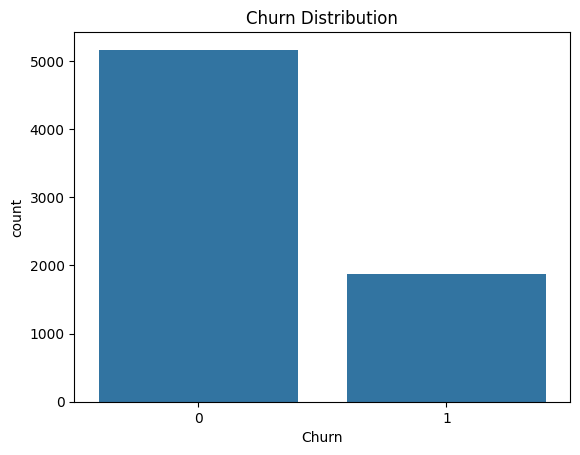

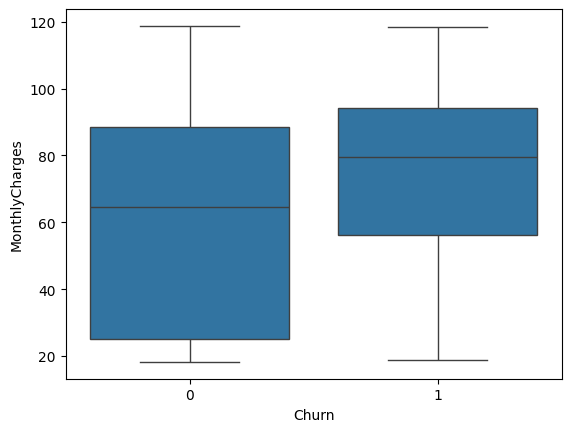

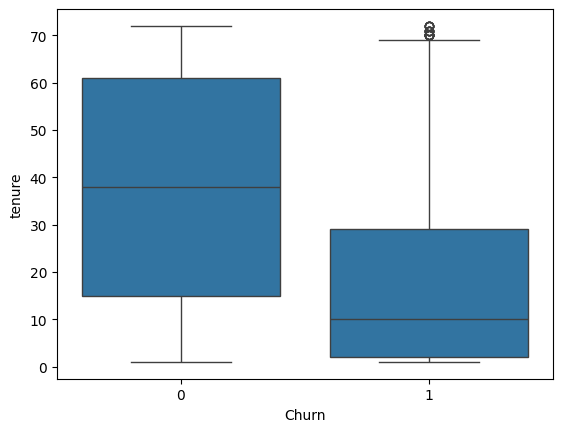

In [6]:
# ============================================
# EDA
# ============================================

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

In [7]:
# ============================================
# FEATURE ENGINEERING
# ============================================

df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

df['ServiceCount'] = (
    (df[['OnlineSecurity','TechSupport']] != 'No')
    .sum(axis=1)
)

In [8]:
# ============================================
# ENCODING
# ============================================

df = pd.get_dummies(df, drop_first=True)

In [9]:
# ============================================
# SPLIT DATA
# ============================================

X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Handle imbalance
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42
)

In [10]:
# ============================================
# MODEL FUNCTIONS
# ============================================

def plot_confusion(cm, title):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_roc_curve(fpr, tpr, roc_auc, name):
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

In [11]:
# ============================================
# MODEL EVALUATION
# ============================================

def evaluate_model(model, params, name):

    grid = GridSearchCV(model, params, cv=3, scoring='recall')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]

    print(f"\n===== {name} =====")

    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plot_confusion(cm, name)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plot_roc_curve(fpr, tpr, roc_auc, name)

    return best_model, y_pred, y_prob


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.80      0.74      0.77      1563
           1       0.76      0.81      0.78      1535

    accuracy                           0.78      3098
   macro avg       0.78      0.78      0.78      3098
weighted avg       0.78      0.78      0.78      3098

Accuracy: 0.7772756617172369


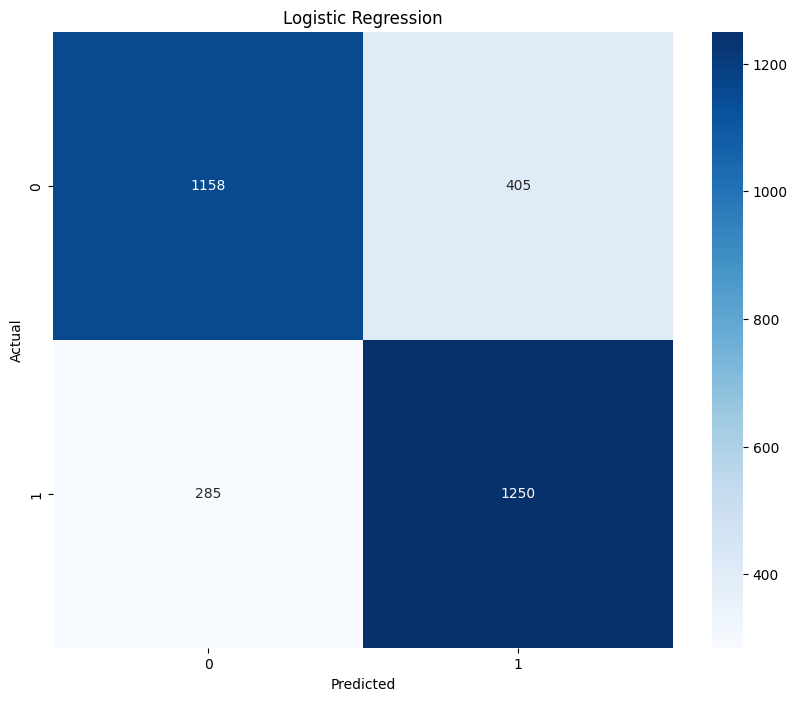


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1563
           1       0.80      0.86      0.83      1535

    accuracy                           0.82      3098
   macro avg       0.82      0.82      0.82      3098
weighted avg       0.82      0.82      0.82      3098

Accuracy: 0.8218205293737896


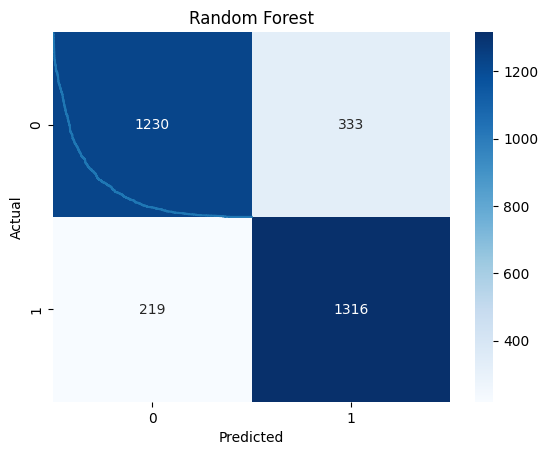


===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1563
           1       0.82      0.87      0.85      1535

    accuracy                           0.84      3098
   macro avg       0.84      0.84      0.84      3098
weighted avg       0.84      0.84      0.84      3098

Accuracy: 0.8431245965138799


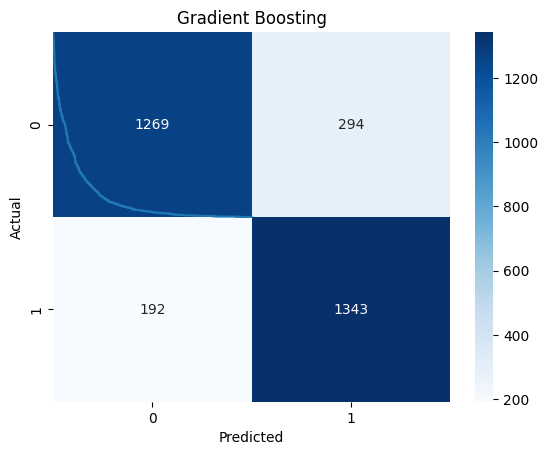


===== KNN =====
              precision    recall  f1-score   support

           0       0.87      0.67      0.76      1563
           1       0.73      0.90      0.81      1535

    accuracy                           0.79      3098
   macro avg       0.80      0.79      0.78      3098
weighted avg       0.80      0.79      0.78      3098

Accuracy: 0.7869593285990962


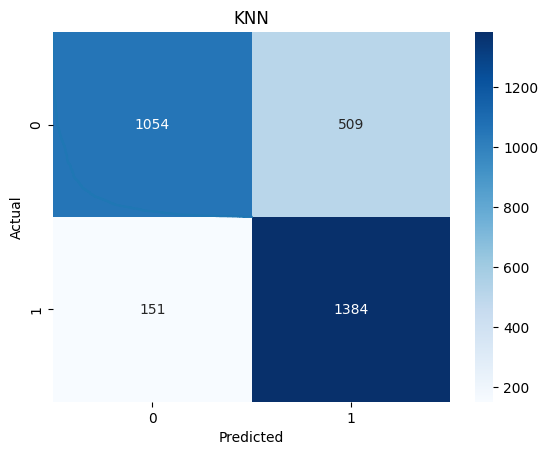


===== SVM =====
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      1563
           1       0.79      0.84      0.81      1535

    accuracy                           0.81      3098
   macro avg       0.81      0.81      0.81      3098
weighted avg       0.81      0.81      0.81      3098

Accuracy: 0.8105229180116204


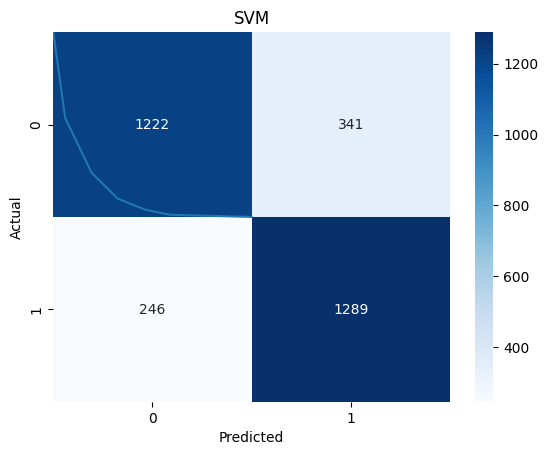


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1563
           1       0.84      0.85      0.85      1535

    accuracy                           0.85      3098
   macro avg       0.85      0.85      0.85      3098
weighted avg       0.85      0.85      0.85      3098

Accuracy: 0.8489347966429954


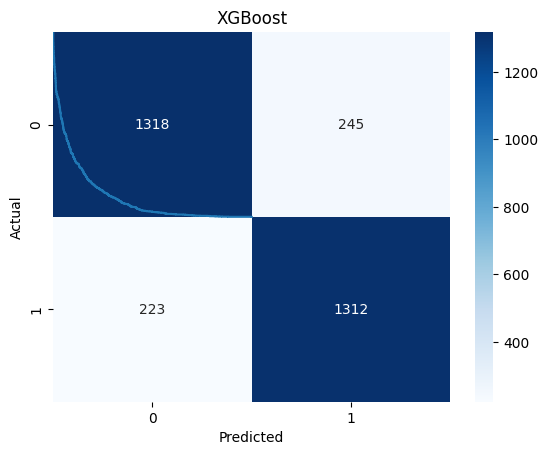

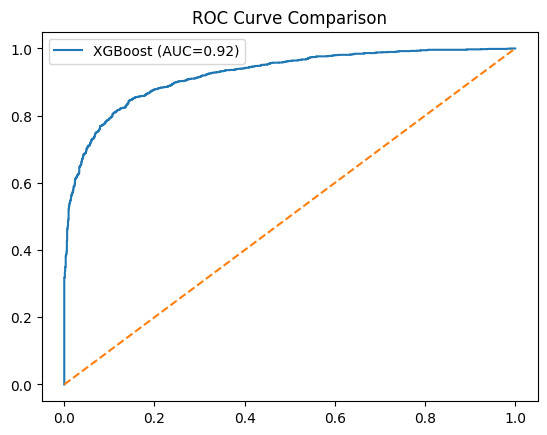

In [12]:
# ============================================
# TRAIN MODELS
# ============================================

plt.figure(figsize=(10,8))

log_model, log_pred, log_prob = evaluate_model(
    LogisticRegression(max_iter=200),
    {'C':[0.1,1,10]},
    "Logistic Regression"
)

rf_model, rf_pred, rf_prob = evaluate_model(
    RandomForestClassifier(),
    {'n_estimators':[100], 'max_depth':[10]},
    "Random Forest"
)

gb_model, gb_pred, gb_prob = evaluate_model(
    GradientBoostingClassifier(),
    {'n_estimators':[100]},
    "Gradient Boosting"
)

knn_model, knn_pred, knn_prob = evaluate_model(
    KNeighborsClassifier(),
    {'n_neighbors':[5]},
    "KNN"
)

svc_model, svc_pred, svc_prob = evaluate_model(
    SVC(probability=True),
    {'C':[1]},
    "SVM"
)

xgb_model, xgb_pred, xgb_prob = evaluate_model(
    XGBClassifier(eval_metric='logloss'),
    {'n_estimators':[200], 'max_depth':[5]},
    "XGBoost"
)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

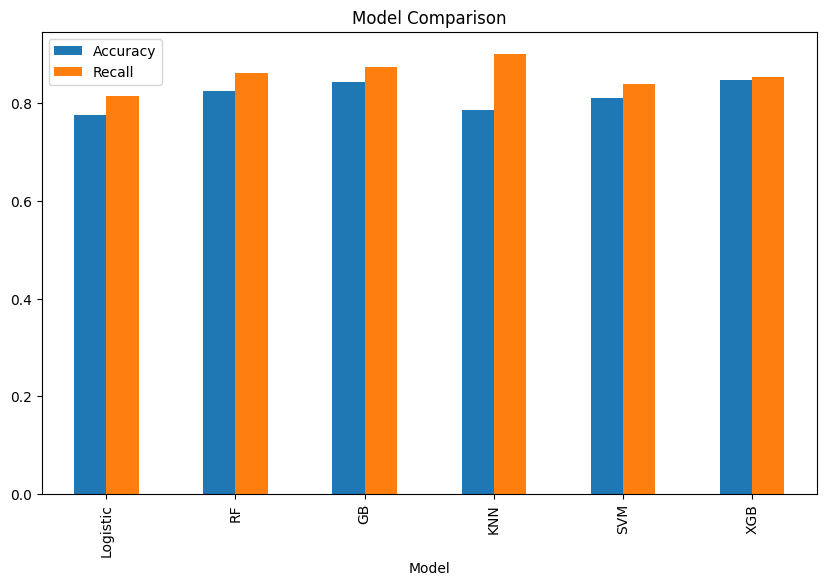

In [ ]:
# ============================================
# METRICS COMPARISON
# ============================================

metrics = pd.DataFrame({
    "Model": ["Logistic","RF","GB","KNN","SVM","XGB"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svc_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, svc_pred),
        recall_score(y_test, xgb_pred)
    ]
})

metrics.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.show()

In [13]:
# ============================================
# FINAL MODEL (XGBOOST)
# ============================================

print("\n========== FINAL MODEL: XGBOOST ==========")

y_prob = xgb_prob
y_pred = (y_prob > 0.4).astype(int)

# ============================================
# METRICS
# ============================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("\n MODEL PERFORMANCE")
print("-"*40)

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f} ⭐")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")

print("\n CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

print("\n CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

# ============================================
# BUSINESS OUTPUT
# ============================================

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Probability": y_prob
})

stay = (y_pred == 0).sum()
churn = (y_pred == 1).sum()

print("\n BUSINESS SUMMARY")
print("-"*40)
print(f"Customers Staying : {stay}")
print(f"Customers Churning: {churn}")

churn_rate = y_pred.mean() * 100
print(f"Churn Rate        : {churn_rate:.2f}%")

# ============================================
# RISK SEGMENTATION
# ============================================

def risk(p):
    if p > 0.7:
        return "High"
    elif p > 0.4:
        return "Medium"
    else:
        return "Low"

results["Risk"] = results["Probability"].apply(risk)

print("\n RISK DISTRIBUTION")
print(results["Risk"].value_counts())

# ============================================
# TOP CUSTOMERS
# ============================================

print("\n TOP 10 HIGH-RISK CUSTOMERS")
print(results.sort_values(by="Probability", ascending=False).head(10))

# ============================================
# SAVE FILE
# ============================================

results.to_csv("churn_predictions.csv", index=False)

print("\n File saved: churn_predictions.csv")


========== FINAL MODEL: XGBOOST ==========

 MODEL PERFORMANCE
----------------------------------------
Accuracy  : 0.8386
Precision : 0.8123
Recall    : 0.8769 ⭐
F1 Score  : 0.8434

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1563
           1       0.81      0.88      0.84      1535

    accuracy                           0.84      3098
   macro avg       0.84      0.84      0.84      3098
weighted avg       0.84      0.84      0.84      3098


 CONFUSION MATRIX
[[1252  311]
 [ 189 1346]]

 BUSINESS SUMMARY
----------------------------------------
Customers Staying : 1441
Customers Churning: 1657
Churn Rate        : 53.49%

 RISK DISTRIBUTION
Risk
Low       1441
High      1308
Medium     349
Name: count, dtype: int64

 TOP 10 HIGH-RISK CUSTOMERS
       Actual  Predicted  Probability  Risk
10234       1          1     1.000000  High
7769        1          1     0.999998  High
7923        1          1  